In [18]:
import seaborn as sns 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.metrics import accuracy_score 
from sklearn.model_selection import KFold 

from sklearn.linear_model import LogisticRegression

from pathlib import Path


In [75]:
def _ret_cols(start, stop):
    return [f"RET_{j}" for j in range(start, stop + 1)]

def _signed_volume_cols(start, stop):
    return [f"SIGNED_VOLUME_{j}" for j in range(start, stop + 1)]

TURNOVER_features = ["MEDIAN_DAILY_TURNOVER"]

ORIGINAL_FEATURES = _ret_cols(1, 20) + _signed_volume_cols(1, 20) + TURNOVER_features

DATE = "TS"
ALLOCATION = "ALLOCATION"
GROUP = "GROUP"
ROW_ID = "ROW_ID"
TARGET = "target"
TARGET_BINARY = "target_binary"

UTILS_COLS = [DATE, ALLOCATION, GROUP]

In [11]:
path_xtrain = "X_train.csv"
path_xtest = "X_test.csv"

X_train = pd.read_csv(path_xtrain,index_col='ROW_ID')
X_test = pd.read_csv(path_xtest,index_col='ROW_ID')

y_train = pd.read_csv('y_train.csv',index_col='ROW_ID')
sample_submission = pd.read_csv('sample_submission.csv',index_col='ROW_ID')

df_train = X_train.join(y_train).assign(target_binary=(y_train >= 0).astype(int))

df_train.shape

(527073, 46)

In [59]:
UNIQUE_TRAIN_DATES = X_train[DATE].unique()
len(UNIQUE_TRAIN_DATES)

2522

In [5]:
# 1 / np.sqrt(50000)

In [60]:
# Creating a holdout 

pct = 0.05 
rng = np.random.default_rng(seed=0)
dates_to_holdout = list(rng.choice(UNIQUE_TRAIN_DATES, int(len(UNIQUE_TRAIN_DATES) * pct)))
indices_to_holdout = df_train.loc[df_train[DATE].isin(dates_to_holdout)].index

df_train_holdout = df_train.loc[indices_to_holdout]
df_train_train = df_train.drop(indices_to_holdout)

In [233]:
def build_features(df):
    df = df.copy()
    df["RET_REV_1"] = - df["RET_1"]
    df["RET_MOM_5"] = df[_ret_cols(1,5)].sum(axis=1)
    df["RET_MOM_6_20"] = df[_ret_cols(6,20)].sum(axis=1)
    df["RET_MOM_20"] = df[_ret_cols(1,20)].sum(axis=1)

    df["RET_RV_20"] = df[_ret_cols(1,20)].pow(2).sum(axis=1).pow(0.5)
    
    df["RET_ACCEL"] = df["RET_MOM_5"] - df["RET_MOM_6_20"] # Si c'est grand ça veut dire que les returns surles 5 derniers jours sont plus grands que les 15 jours d'avant

    df["ISNA_SIGNED_VOLUME_1"] = df["SIGNED_VOLUME_1"].isna() # feature propre à notre dataset
    df["LIQUIDITY_EXPOSURE_5"] = df[_signed_volume_cols(1,5)].mean(axis=1)
    df["LIQUIDITY_EXPOSURE_20"] = df[_signed_volume_cols(1,20)].mean(axis=1)
    
    df["ABS_LIQUIDITY_EXPOSURE_5"] = df["LIQUIDITY_EXPOSURE_5"].abs()
    df["ABS_LIQUIDITY_EXPOSURE_20"] = df["LIQUIDITY_EXPOSURE_20"].abs()

    df["LIQUIDITY_EXPOSURE_RV"] = df[_signed_volume_cols(1,20)].pow(2).sum(axis=1).pow(0.5)

    # interactions 

    df["COST_AWARE_MOM_5"] = df["RET_MOM_5"] / (1 + df["MEDIAN_DAILY_TURNOVER"])
    df["COST_AWARE_MOM_20"] = df["RET_MOM_20"] / (1 + df["MEDIAN_DAILY_TURNOVER"])
    df["COST_AWARE_RET_ACCEL"] = df["RET_ACCEL"] / (1 + df["MEDIAN_DAILY_TURNOVER"])

    df["LIQUIDITY_AWARE_MOM_5"] = df["RET_MOM_5"] * np.sqrt(df["ABS_LIQUIDITY_EXPOSURE_5"]) # si t'es exposé à la liquidité alors ton momentum augmente ? 
    df["LIQUIDITY_AWARE_MOM_20"] = df["RET_MOM_20"] * np.sqrt(df["ABS_LIQUIDITY_EXPOSURE_20"])

    df["MKT_MOM_5"] = df.groupby(DATE)["RET_MOM_5"].transform("median") # momentum du marché
    df["MKT_MOM_DISPERSION"] = df.groupby(DATE)["RET_MOM_5"].transform("std") # est ce que tout le monde gagne ou pas ? 
    df["MKT_MOM_SKEW"] = df.groupby(DATE)["RET_MOM_5"].transform("skew") # y a t il bcp de gagnants ? 

    df["LIQUIDITY_MKT_MOM_5"] = df["MKT_MOM_5"] * df["LIQUIDITY_EXPOSURE_5"] # si t'es exposé à la liquidité + mkt à du momentum alors tu vas gagner ? 

    return df 

FEATURES_REGISTRY = [
    "RET_REV_1",
    "RET_MOM_5",
    "RET_MOM_6_20",
    "RET_MOM_20",
    "RET_RV_20",
    "RET_ACCEL",
    "ISNA_SIGNED_VOLUME_1",
    "LIQUIDITY_EXPOSURE_5",
    "LIQUIDITY_EXPOSURE_20",
    "ABS_LIQUIDITY_EXPOSURE_5",
    "ABS_LIQUIDITY_EXPOSURE_20",
    "LIQUIDITY_EXPOSURE_RV",
    "COST_AWARE_MOM_5",
    "COST_AWARE_MOM_20",
    "COST_AWARE_RET_ACCEL",
    "LIQUIDITY_AWARE_MOM_5",
    "LIQUIDITY_AWARE_MOM_20",
    "MKT_MOM_5",
    "MKT_MOM_DISPERSION",
    "MKT_MOM_SKEW",
    "LIQUIDITY_MKT_MOM_5",
]

MKT_STATE = ["MKT_MOM_5" ,"MKT_MOM_DISPERSION", "MKT_MOM_SKEW"]

In [234]:
f_eng_df = build_features(df_train_train.drop(columns=[TARGET, TARGET_BINARY]))

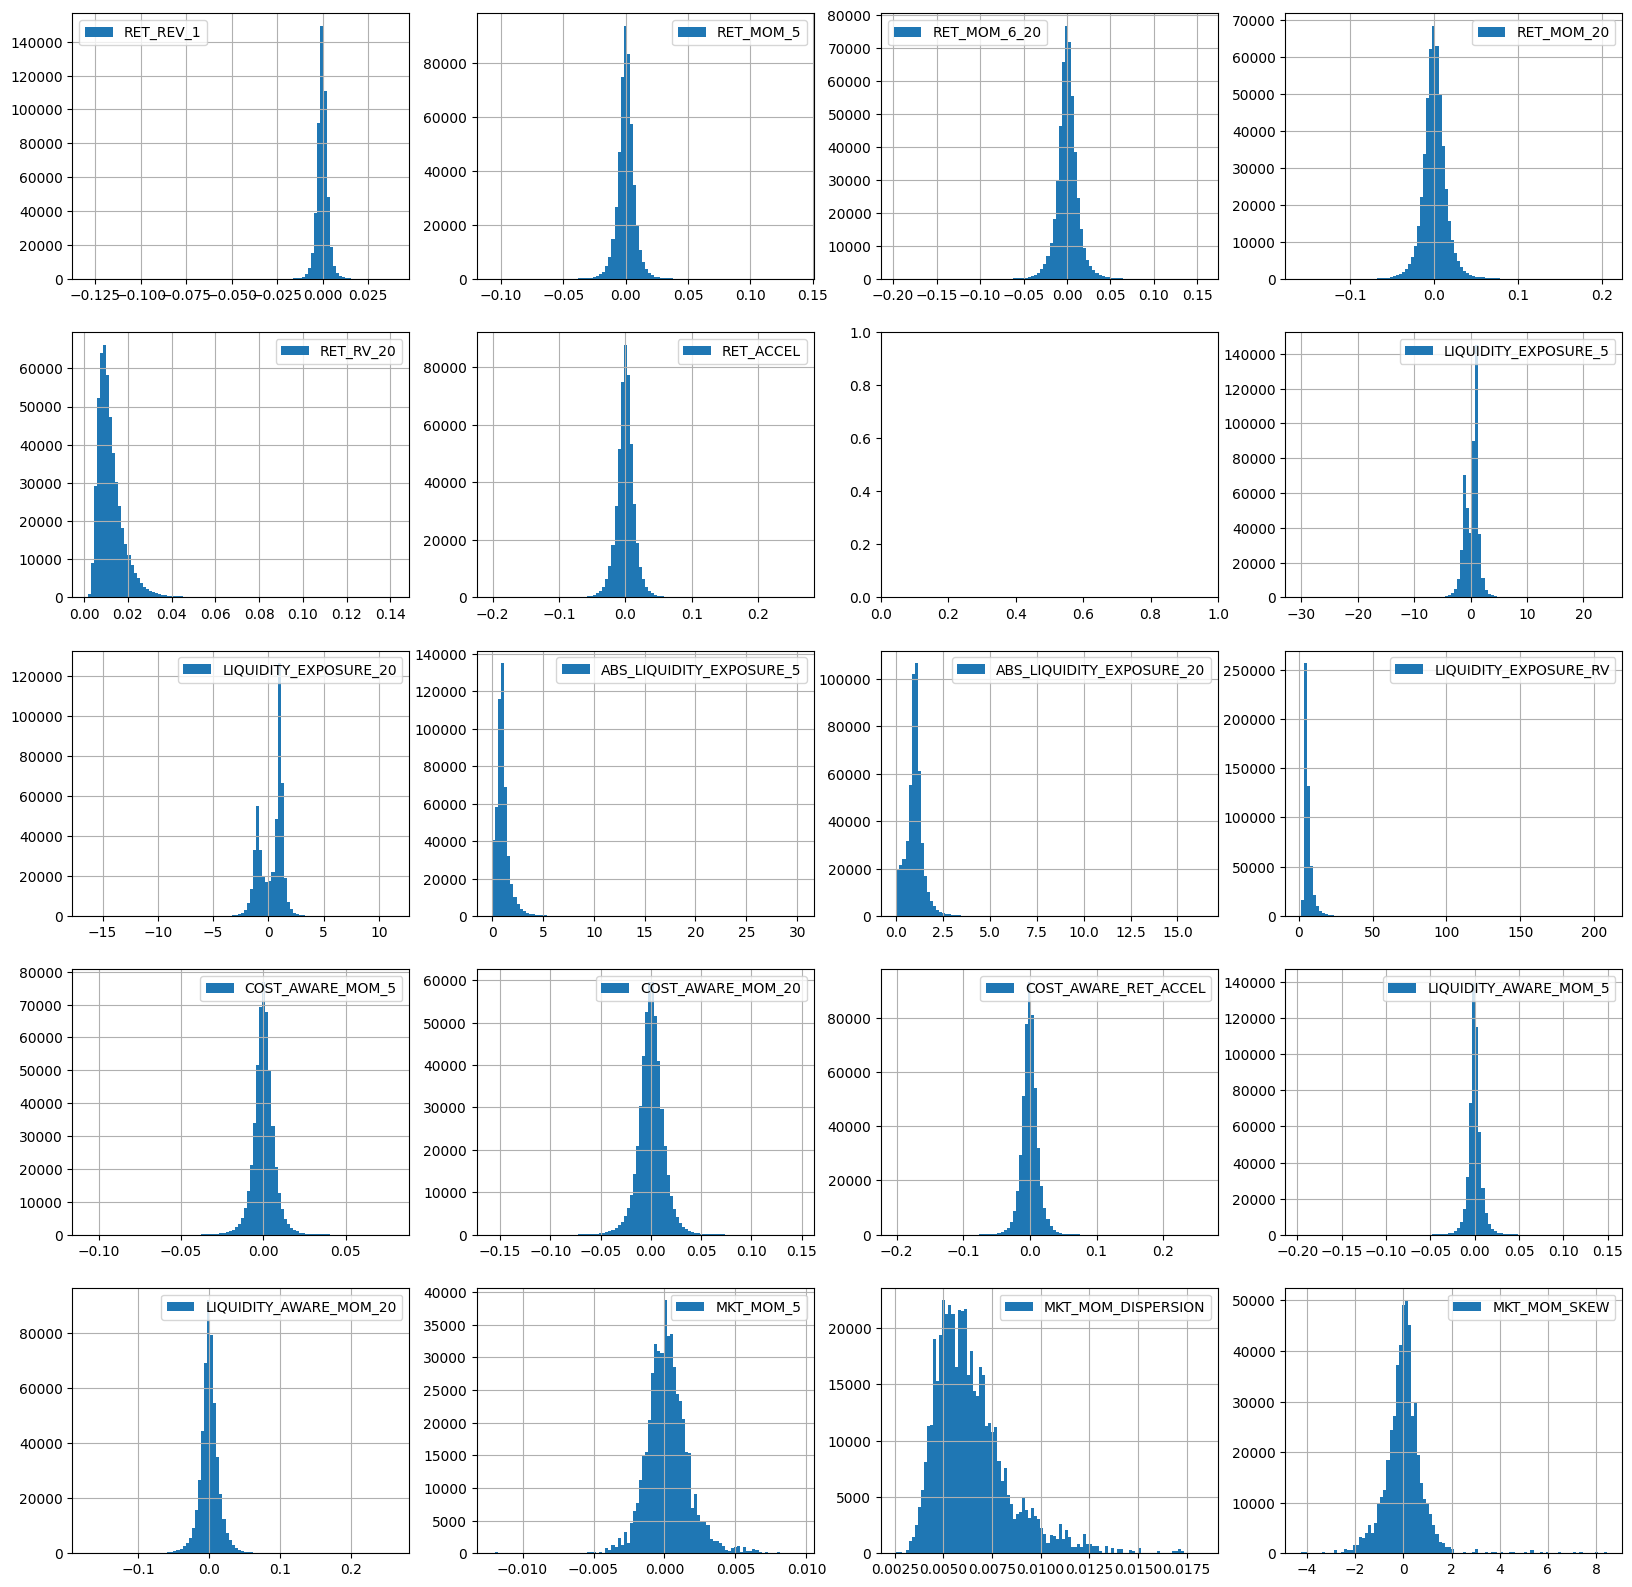

In [235]:
_, axs = plt.subplots(5, 4, figsize=(20, 20))
axs = axs.flatten()
for feat, ax in zip(FEATURES_REGISTRY, axs):
   if feat != "ISNA_SIGNED_VOLUME_1":
      f_eng_df[feat].hist(bins=100, ax=ax, label=feat)
      ax.legend()
plt.show()


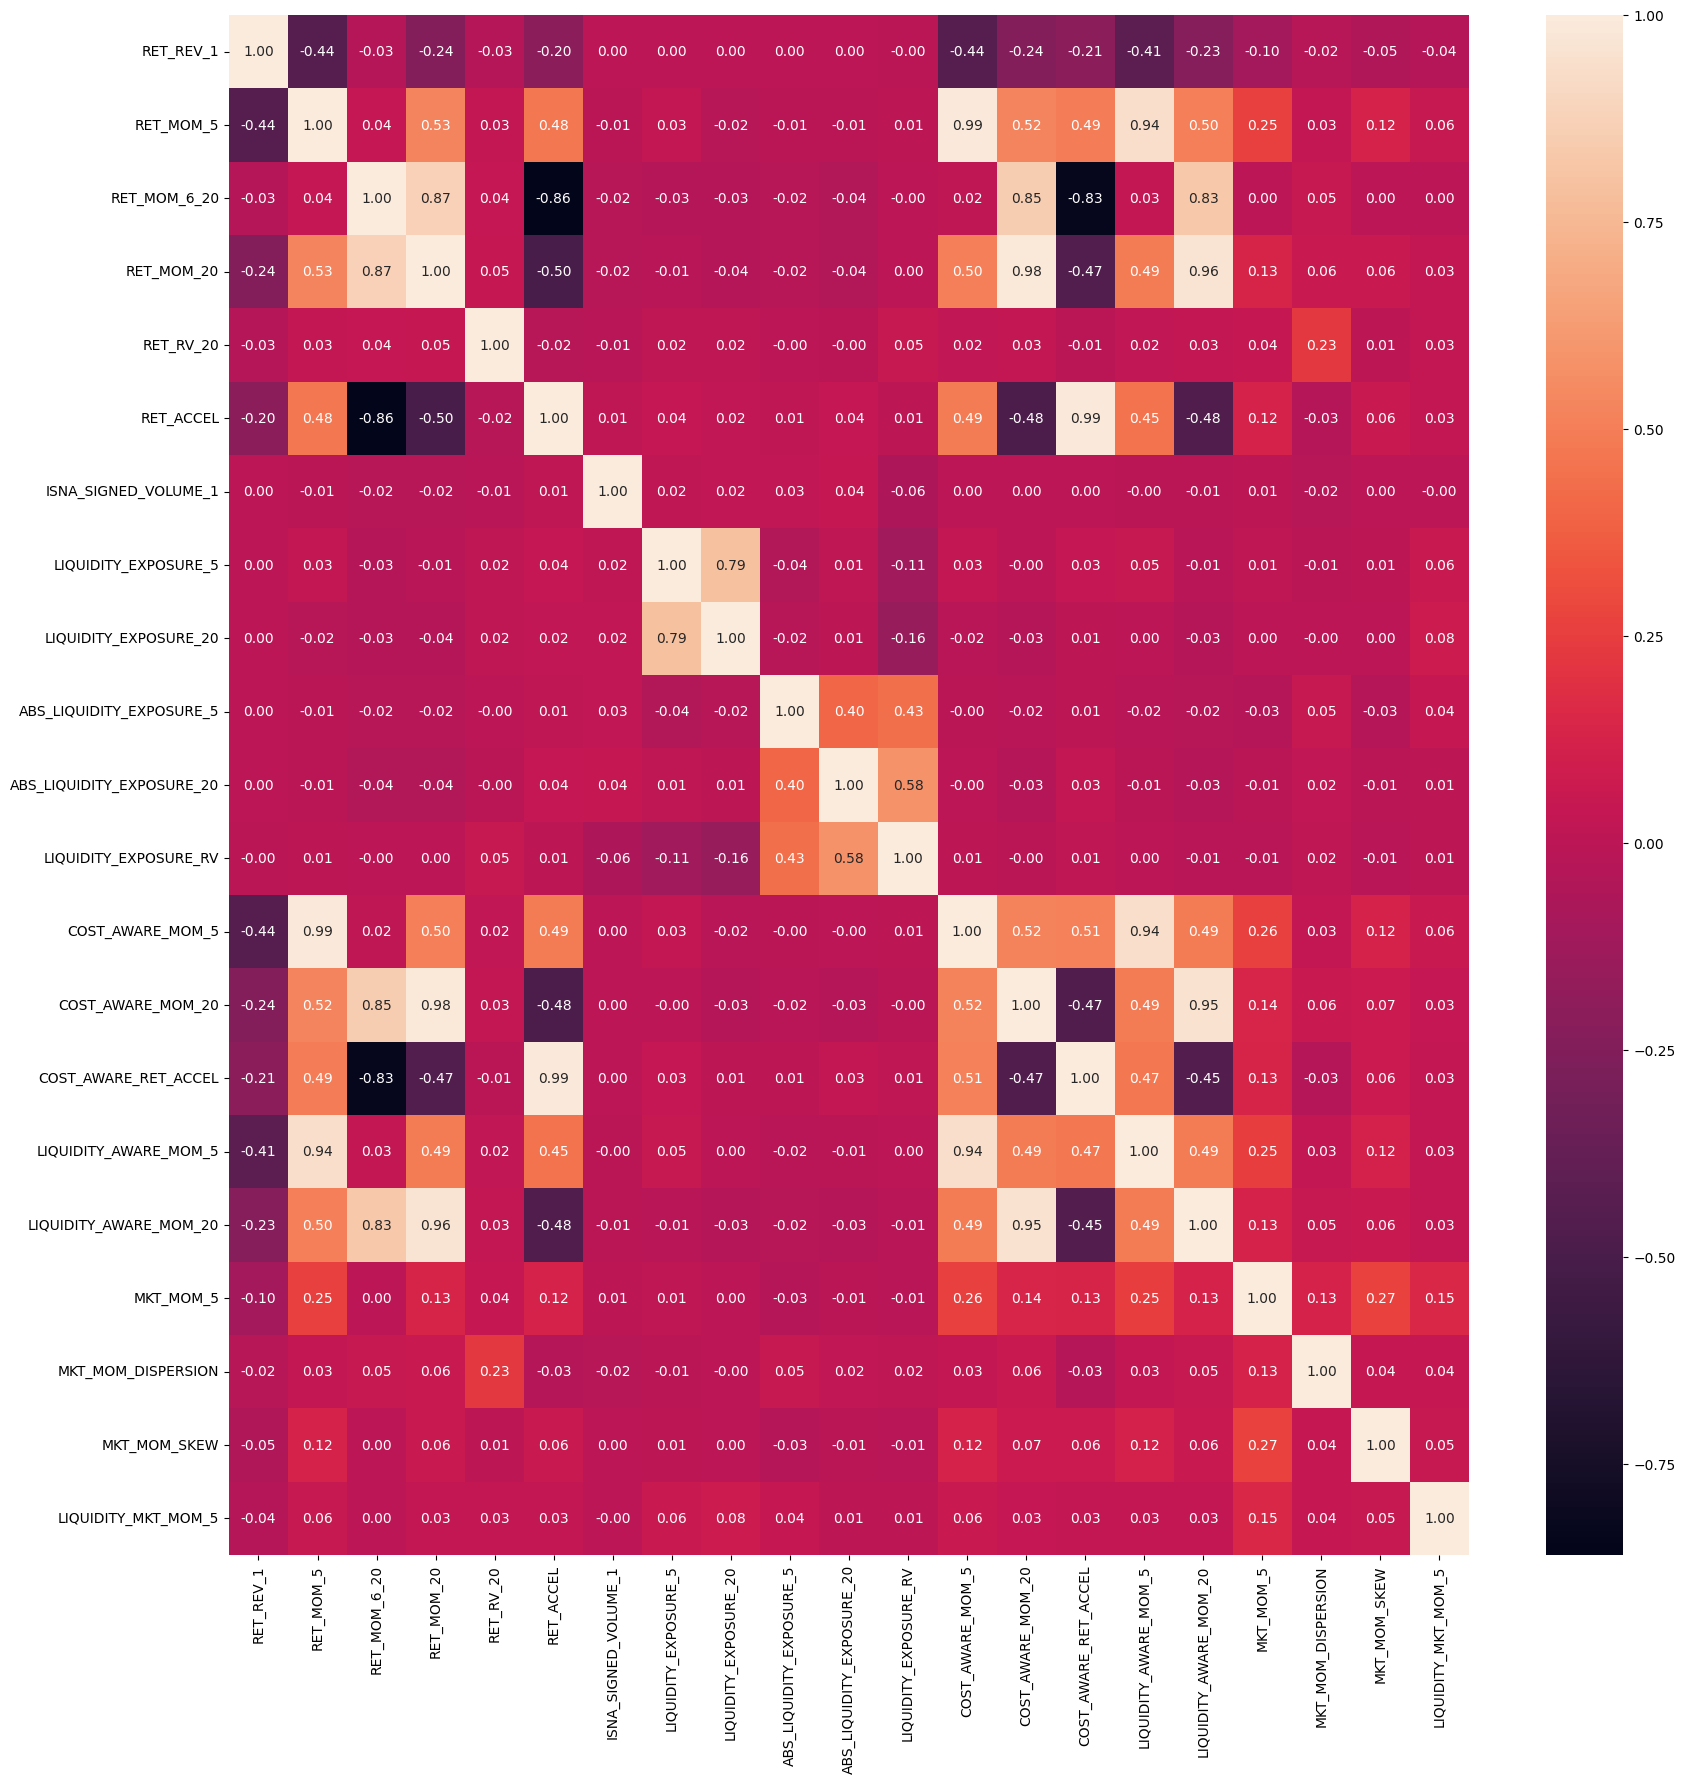

In [236]:
_, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(f_eng_df[FEATURES_REGISTRY].corr(), ax=ax, annot=True , fmt=".2f")
plt.show()

<Axes: >

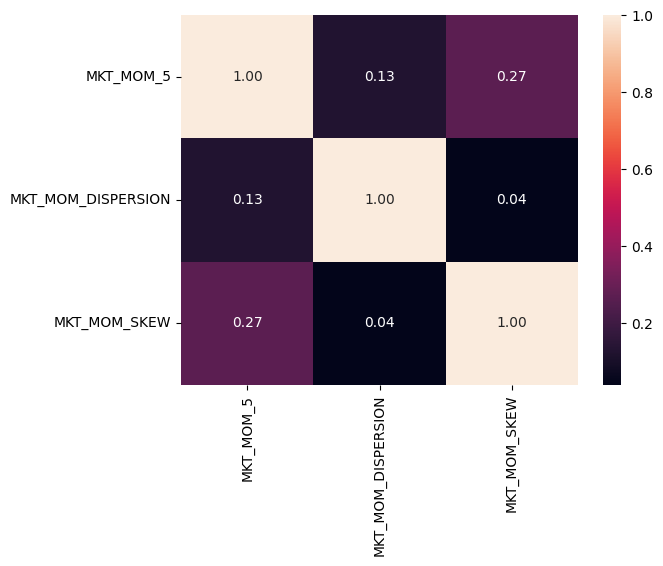

In [237]:
sns.heatmap(f_eng_df[MKT_STATE].corr(), annot=True , fmt=".2f")

In [238]:
from sklearn.feature_selection import mutual_info_classif, f_classif

mi = mutual_info_classif(f_eng_df[FEATURES_REGISTRY].fillna(0), df_train_train[TARGET_BINARY].squeeze(), random_state=0)
mi = pd.Series(mi, index=FEATURES_REGISTRY, name="mutual_information").sort_values(ascending=False)


mi

ISNA_SIGNED_VOLUME_1         0.054885
MKT_MOM_SKEW                 0.014004
MKT_MOM_DISPERSION           0.012896
MKT_MOM_5                    0.012698
LIQUIDITY_MKT_MOM_5          0.001855
LIQUIDITY_AWARE_MOM_20       0.000856
ABS_LIQUIDITY_EXPOSURE_5     0.000702
LIQUIDITY_EXPOSURE_20        0.000512
RET_ACCEL                    0.000509
RET_MOM_5                    0.000484
LIQUIDITY_EXPOSURE_5         0.000370
RET_MOM_20                   0.000339
RET_MOM_6_20                 0.000253
RET_REV_1                    0.000225
COST_AWARE_RET_ACCEL         0.000222
ABS_LIQUIDITY_EXPOSURE_20    0.000098
LIQUIDITY_AWARE_MOM_5        0.000000
COST_AWARE_MOM_20            0.000000
COST_AWARE_MOM_5             0.000000
LIQUIDITY_EXPOSURE_RV        0.000000
RET_RV_20                    0.000000
Name: mutual_information, dtype: float64

In [239]:
f_statistic, p_values = f_classif(f_eng_df[FEATURES_REGISTRY].fillna(0), df_train_train[TARGET_BINARY].squeeze())

res_f_classif = pd.DataFrame({"stat":f_statistic, "p_val":p_values}, index=FEATURES_REGISTRY).sort_values("p_val")



res_f_classif

,stat,p_val
RET_REV_1,1010.433453,1.615272e-221
RET_MOM_20,183.538931,8.320715e-42
RET_MOM_6_20,158.137047,2.925450e-36
LIQUIDITY_AWARE_MOM_20,135.108944,3.154482e-31
COST_AWARE_MOM_20,86.980479,1.100224e-20
ISNA_SIGNED_VOLUME_1,85.232205,2.662932e-20
RET_ACCEL,66.003444,4.511467e-16
LIQUIDITY_EXPOSURE_20,40.425770,2.044046e-10
RET_MOM_5,33.306774,7.875424e-09
LIQUIDITY_EXPOSURE_5,30.484297,3.367464e-08


In [240]:
res_f_classif.index

Index(['RET_REV_1', 'RET_MOM_20', 'RET_MOM_6_20', 'LIQUIDITY_AWARE_MOM_20',
       'COST_AWARE_MOM_20', 'ISNA_SIGNED_VOLUME_1', 'RET_ACCEL',
       'LIQUIDITY_EXPOSURE_20', 'RET_MOM_5', 'LIQUIDITY_EXPOSURE_5',
       'COST_AWARE_RET_ACCEL', 'MKT_MOM_5', 'LIQUIDITY_AWARE_MOM_5',
       'COST_AWARE_MOM_5', 'MKT_MOM_SKEW', 'RET_RV_20',
       'LIQUIDITY_EXPOSURE_RV', 'ABS_LIQUIDITY_EXPOSURE_20',
       'MKT_MOM_DISPERSION', 'LIQUIDITY_MKT_MOM_5',
       'ABS_LIQUIDITY_EXPOSURE_5'],
      dtype='object')

In [241]:
# c'est genial c'est pas les memes !

top_5_non_linear = mi.iloc[:5]
top_5_linear = res_f_classif.iloc[:5]
top_10_non_linear = mi.iloc[:10]
top_10_linear = res_f_classif.iloc[:10]
print(top_5_linear.index.intersection(top_5_non_linear.index))
print(top_10_linear.index.intersection(top_10_non_linear.index))

Index([], dtype='object')
Index(['LIQUIDITY_AWARE_MOM_20', 'ISNA_SIGNED_VOLUME_1', 'RET_ACCEL',
       'LIQUIDITY_EXPOSURE_20', 'RET_MOM_5'],
      dtype='object')


In [242]:
def preprocess(df):
    df = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns 
    means = df.groupby(DATE)[num_cols].transform("median")
    df[num_cols] = df[num_cols].fillna(means)
    return df 

In [243]:
from sklearn.base import clone 
from sklearn.preprocessing import StandardScaler, MinMaxScaler

N_SPLITS = 12 
SHUFFLE = True 
RANDOM_STATE = 0 

def evaluate_model(X, y, model, features, n_splits=8, thresh=0.5, seed=0, verbose=False):


    unique_ts = X[DATE].unique()
    oof_pred = pd.DataFrame(np.nan, index=y.index, dtype=float, columns=["oof_proba", "oof_pred"])
    splitter = KFold(
        n_splits=N_SPLITS,
        shuffle=SHUFFLE,
        random_state=RANDOM_STATE,
    )
    
    models = []
    scores = []

    for fold_id, (train_date_idx, valid_date_idx) in enumerate(splitter.split(unique_ts), start=1):
        train_dates = unique_ts[train_date_idx]
        valid_dates = unique_ts[valid_date_idx]

        train_mask = X[DATE].isin(train_dates)
        valid_mask = X[DATE].isin(valid_dates)

        X_train_fold = X.loc[train_mask]
        X_test_fold = X.loc[valid_mask]

        y_train_fold = y.loc[train_mask]
        y_test_fold = y.loc[valid_mask]

        local_model = clone(model)

        #### Build Features + Fillna #####

        X_train_fold = build_features(X_train_fold)
        X_test_fold = build_features(X_test_fold)

        X_train_fold = X_train_fold[UTILS_COLS + features]
        X_test_fold = X_test_fold[UTILS_COLS + features]

        X_train_fold = preprocess(X_train_fold).fillna(0)[features]
        X_test_fold = preprocess(X_test_fold).fillna(0)[features]

        #### Standardizing

        scaler = StandardScaler()

        X_train_fold = scaler.fit_transform(X_train_fold)
        X_test_fold = scaler.transform(X_test_fold)

        local_model.fit(X_train_fold, y_train_fold)

        y_train_proba = local_model.predict_proba(X_train_fold)[:, 1]
        y_test_proba = local_model.predict_proba(X_test_fold)[:, 1]
        
        y_train_preds = (y_train_proba >= thresh).astype(int)
        y_test_preds = (y_test_proba >= thresh).astype(int)

        oof_pred.loc[train_mask, "oof_proba"] = y_train_preds
        oof_pred.loc[valid_mask, "oof_pred"] = y_test_preds
        
        models.append(local_model)

        score_train = accuracy_score(y_train_fold, y_train_preds)
        score_test = accuracy_score(y_test_fold, y_test_preds)
        scores.append(score_test)
        
        if verbose:
            print(f"Fold {fold_id}")
            print(f" - Fold size train: {len(y_train_fold)} - Fold size test: {len(y_test_fold)}")
            print(f" - Accuracy train: {score_train:.6f} | Accuracy test: {score_test:.6f}")
            print(f" - Ratio Positive rate train: {y_train_preds.mean() / y_train_fold.mean():.4f} | Ratio Positive rate test: {y_test_preds.mean() / y_test_fold.mean():.4f}")

    mean = np.mean(scores)
    std = np.std(scores)

    if verbose:
        print(f"- Score: {mean:.6f} [{mean-std:.6f} : {mean+std:.6f}] (+- {std:.6f})")

    return models, scores, oof_pred



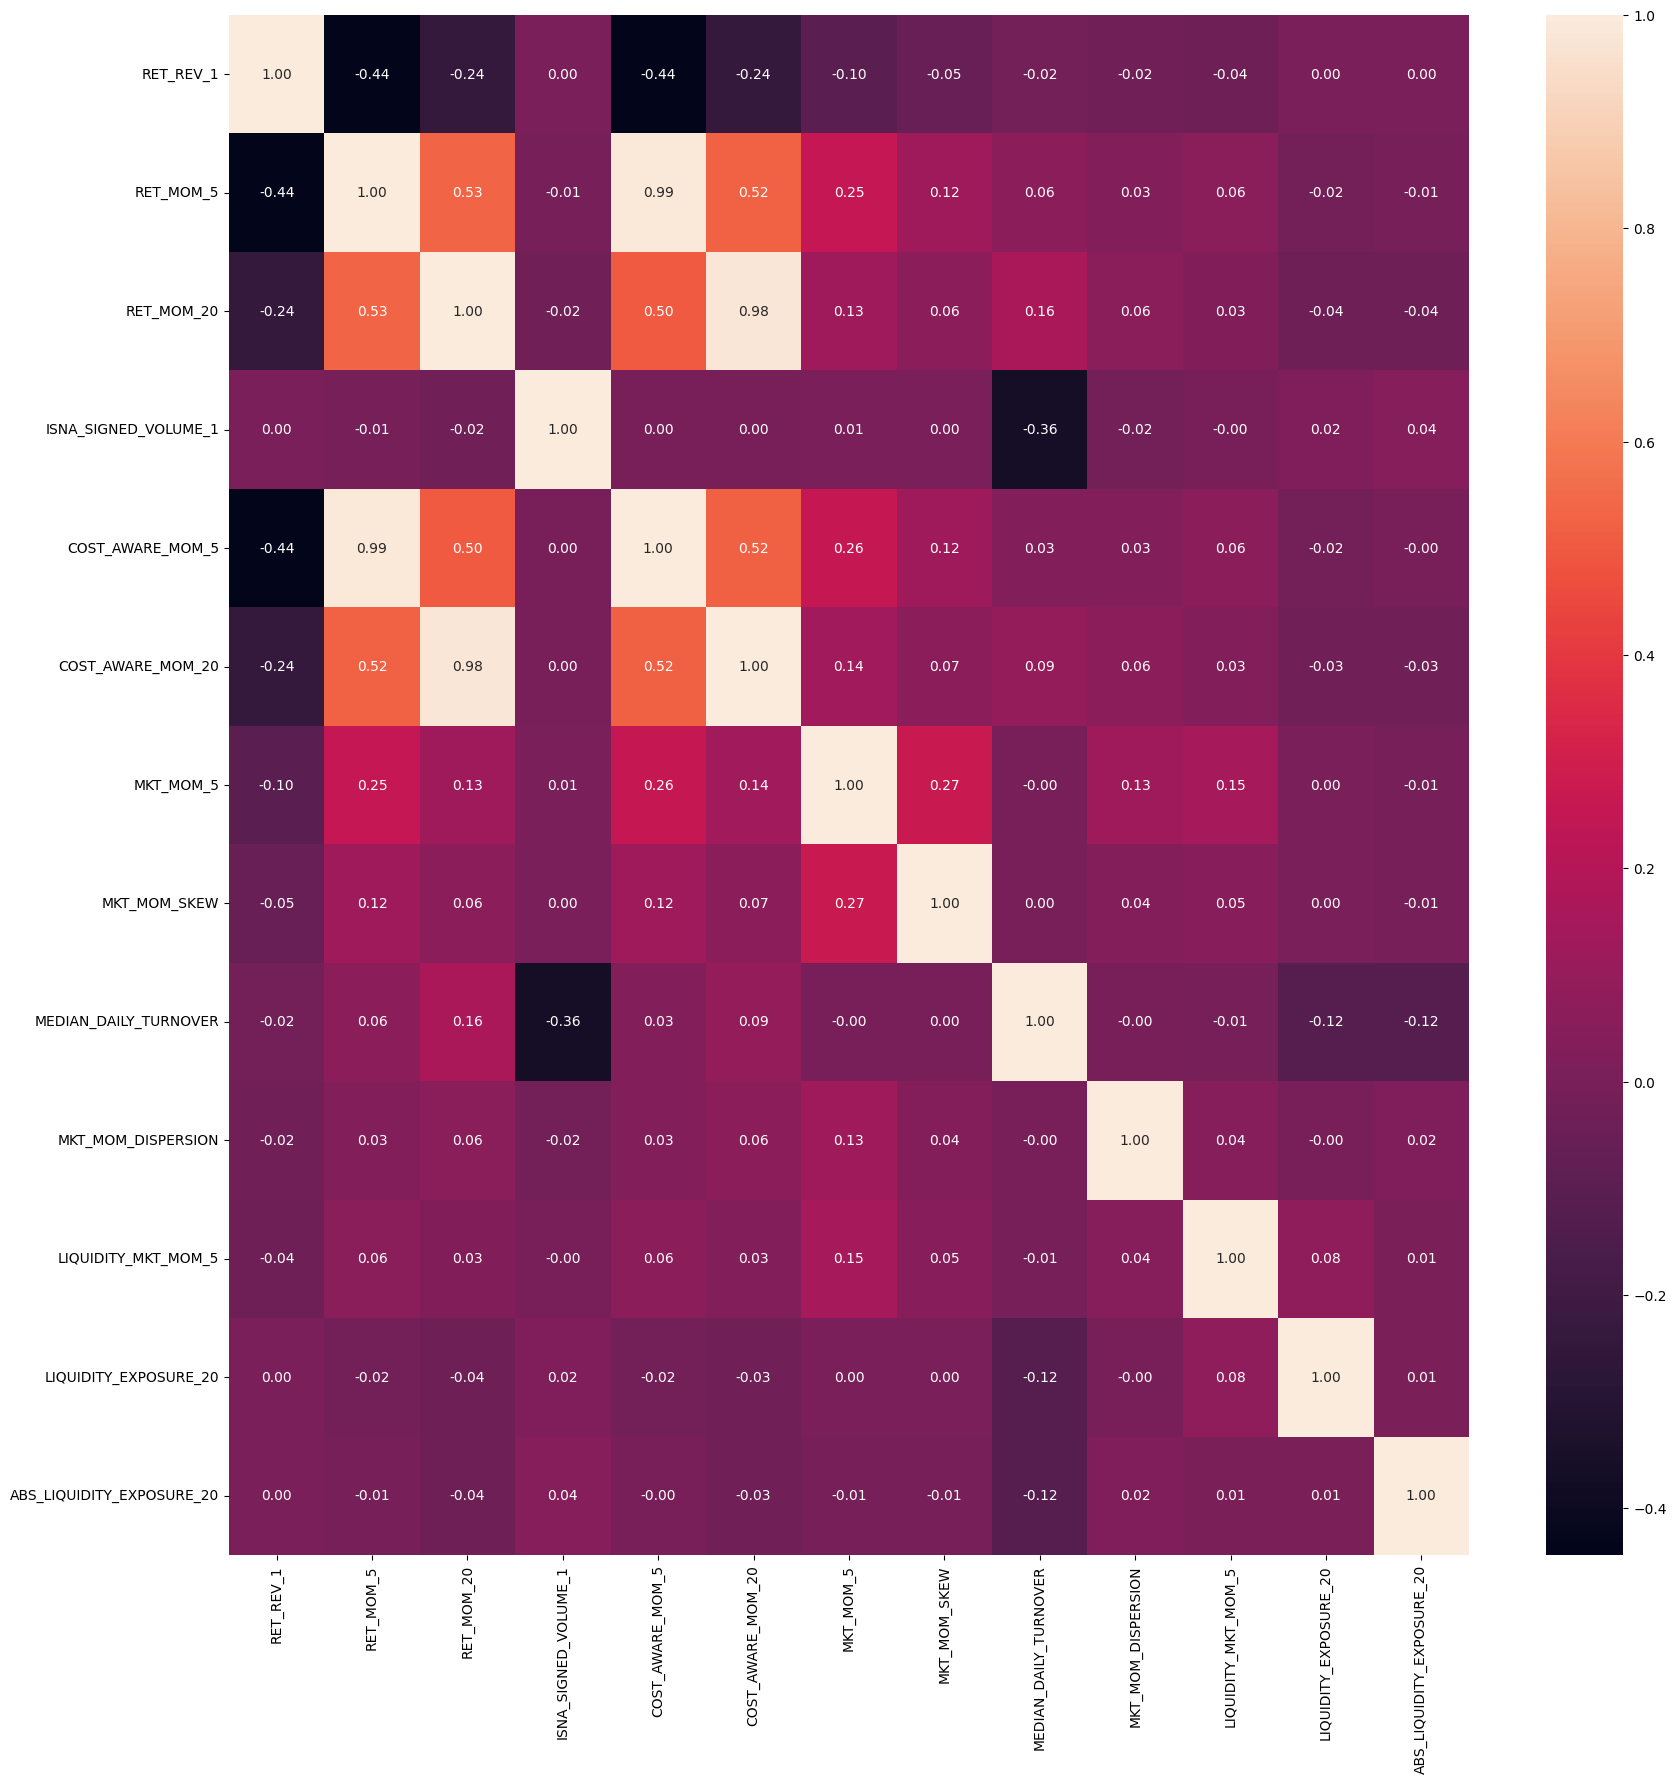

Fold 1
 - Fold size train: 458998 - Fold size test: 41043
 - Accuracy train: 0.523100 | Accuracy test: 0.525303
 - Ratio Positive rate train: 1.3207 | Ratio Positive rate test: 1.3181
Fold 2
 - Fold size train: 457911 - Fold size test: 42130
 - Accuracy train: 0.523973 | Accuracy test: 0.518182
 - Ratio Positive rate train: 1.2756 | Ratio Positive rate test: 1.2553
Fold 3
 - Fold size train: 459681 - Fold size test: 40360
 - Accuracy train: 0.522800 | Accuracy test: 0.528915
 - Ratio Positive rate train: 1.2390 | Ratio Positive rate test: 1.2084
Fold 4
 - Fold size train: 457619 - Fold size test: 42422
 - Accuracy train: 0.524406 | Accuracy test: 0.515134
 - Ratio Positive rate train: 1.2833 | Ratio Positive rate test: 1.2884
Fold 5
 - Fold size train: 458298 - Fold size test: 41743
 - Accuracy train: 0.522743 | Accuracy test: 0.528879
 - Ratio Positive rate train: 1.3186 | Ratio Positive rate test: 1.3170
Fold 6
 - Fold size train: 459371 - Fold size test: 40670
 - Accuracy train: 0.5

In [304]:
params = {"l1_ratio":0.8, "tol":1e-4, "C":1e-3, "max_iter":int(1e5), "solver":"saga", "penalty":"elasticnet"}
model = LogisticRegression(**params)
features = [
    "RET_REV_1",
    "RET_MOM_5",
    "RET_MOM_20",
    # "RET_ACCEL",
    "ISNA_SIGNED_VOLUME_1",

    
    
    "COST_AWARE_MOM_5",
    "COST_AWARE_MOM_20",

    # "LIQUIDITY_AWARE_MOM_20",
    
    
    "MKT_MOM_5",
    "MKT_MOM_SKEW",
    "MEDIAN_DAILY_TURNOVER",
    "MKT_MOM_DISPERSION",


    
    "LIQUIDITY_MKT_MOM_5",

    # "COST_AWARE_RET_ACCEL",
    # "LIQUIDITY_AWARE_MOM_5",
    # "LIQUIDITY_EXPOSURE_5",
    "LIQUIDITY_EXPOSURE_20",
    # "ABS_LIQUIDITY_EXPOSURE_5",
    "ABS_LIQUIDITY_EXPOSURE_20",
    # "LIQUIDITY_EXPOSURE_RV",
    # "RET_RV_20",

]

_, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(build_features(df_train_train)[features].corr(), ax=ax, annot=True , fmt=".2f")
plt.show()

models, scores, scores_oof = evaluate_model(
    X=df_train_train,
    y=df_train_train[TARGET_BINARY].squeeze(),
    model=model,
    features=features,
    verbose=True,
)

<Axes: >

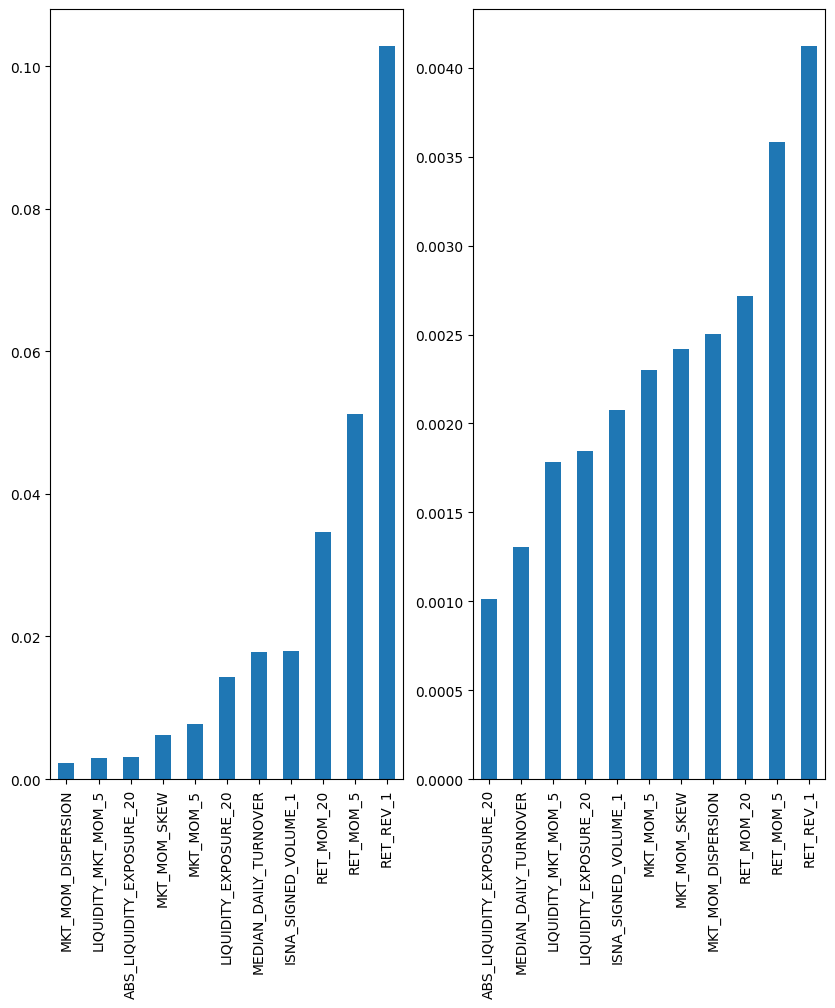

In [300]:
res = pd.DataFrame({f"model{i+1}":model.coef_.squeeze() for i, model in enumerate(models)}, index=features)
res = res.assign(mean_coef=res.mean(axis=1), std_coef=res.std(axis=1))


_, ax = plt.subplots(1, 2, figsize=(10, 10))
res["mean_coef"].abs().sort_values().plot(kind="bar", ax=ax[0])

res["std_coef"].abs().sort_values().plot(kind="bar", ax=ax[1])

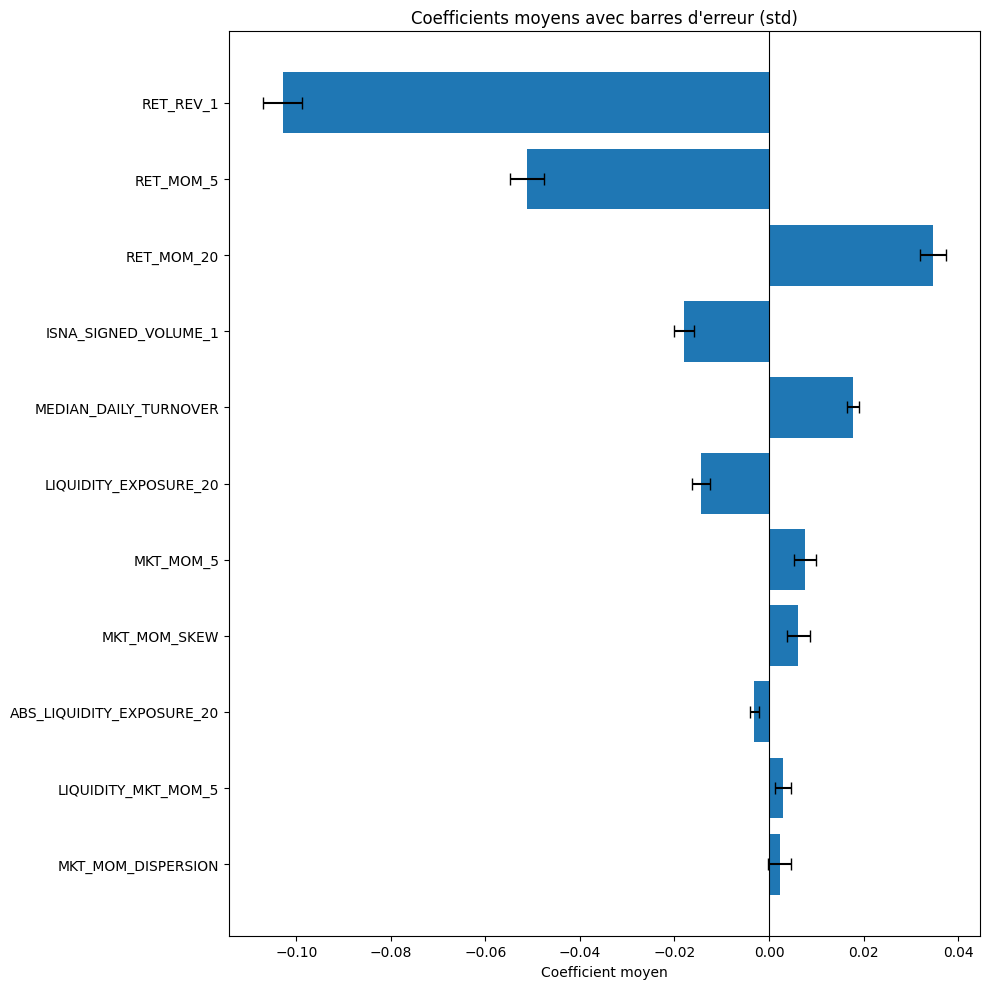

In [301]:
res_plot = res.reindex(res["mean_coef"].abs().sort_values().index)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(
    res_plot.index,
    res_plot["mean_coef"],
    xerr=res_plot["std_coef"],
    capsize=4
)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient moyen")
ax.set_title("Coefficients moyens avec barres d'erreur (std)")
plt.tight_layout()
plt.show()

In [273]:
diagnostic_df = scores_oof.join(build_features(df_train_train)[[TARGET_BINARY, DATE, ALLOCATION, GROUP] + FEATURES_REGISTRY + TURNOVER_features])
    
feat_to_bin = MKT_STATE + TURNOVER_features + ["ABS_LIQUIDITY_EXPOSURE_20"]

diagnostic_df = diagnostic_df.assign(
        is_correct=lambda x: x["oof_pred"] == x[TARGET_BINARY].astype(int),
        **{
            f"{col}_qcut": pd.qcut(diagnostic_df[col], q=5, duplicates="drop", labels=False)
            for col in feat_to_bin
        }
    )


<Axes: ylabel='Frequency'>

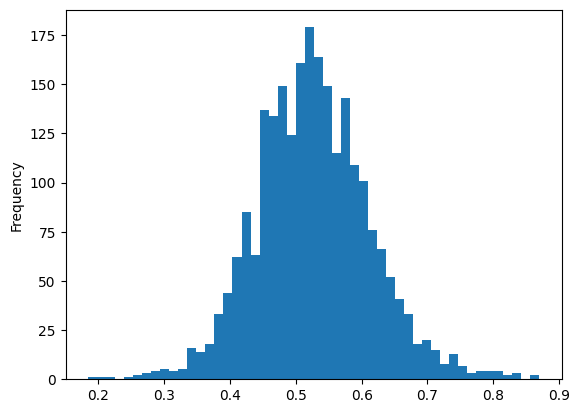

In [274]:
diagnostic_df.groupby(DATE)["is_correct"].mean().plot(kind="hist", bins=50)

In [275]:
diagnostic_df.groupby(DATE)["is_correct"].mean().agg(["mean", "std", "skew"])

mean    0.526643
std     0.086421
skew    0.223199
Name: is_correct, dtype: float64

<Axes: ylabel='Frequency'>

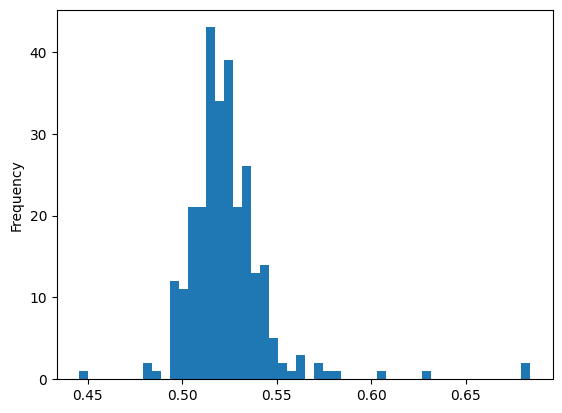

In [276]:
diagnostic_df.groupby(ALLOCATION)["is_correct"].mean().plot(kind="hist", bins=50)

In [277]:
diagnostic_df.groupby(ALLOCATION)["is_correct"].mean().agg(["mean", "std", "skew"])

mean    0.523370
std     0.022837
skew    3.044744
Name: is_correct, dtype: float64

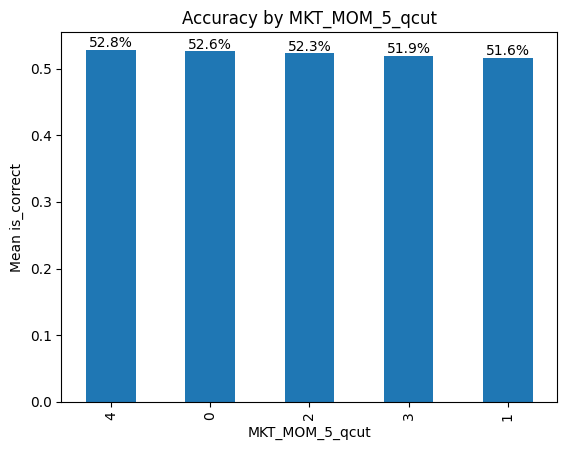

In [278]:
ax = (
    diagnostic_df.groupby("MKT_MOM_5_qcut")["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar")
)

ax.set_ylabel("Mean is_correct")
ax.set_xlabel("MKT_MOM_5_qcut")
ax.set_title("Accuracy by MKT_MOM_5_qcut")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

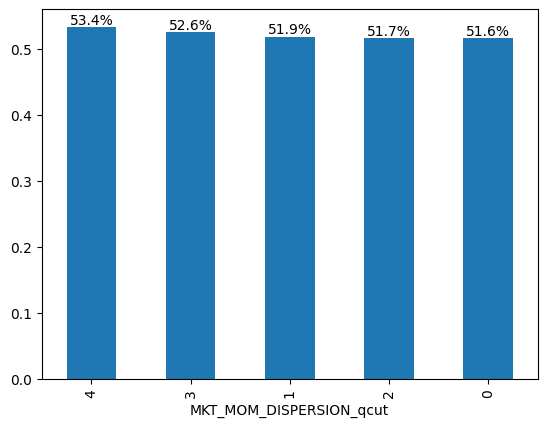

In [288]:
ax = (
    diagnostic_df.groupby("MKT_MOM_DISPERSION_qcut")["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar")
)


for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

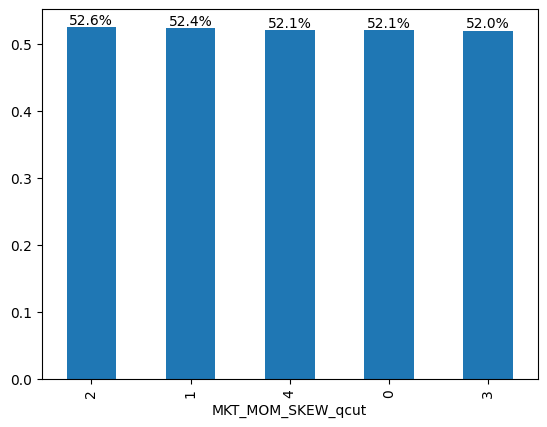

In [289]:
ax = (
    diagnostic_df.groupby("MKT_MOM_SKEW_qcut")["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar")
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

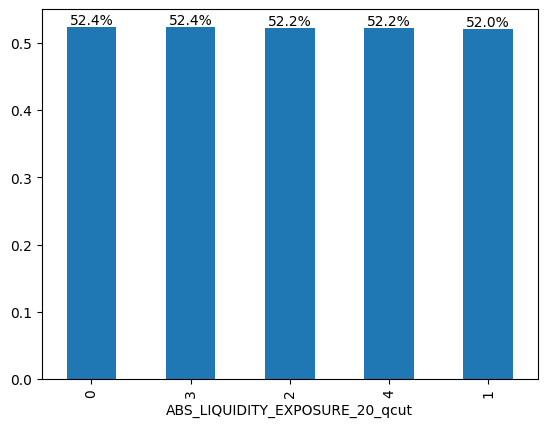

In [290]:
ax = (
    diagnostic_df.groupby('ABS_LIQUIDITY_EXPOSURE_20_qcut')["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar")
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

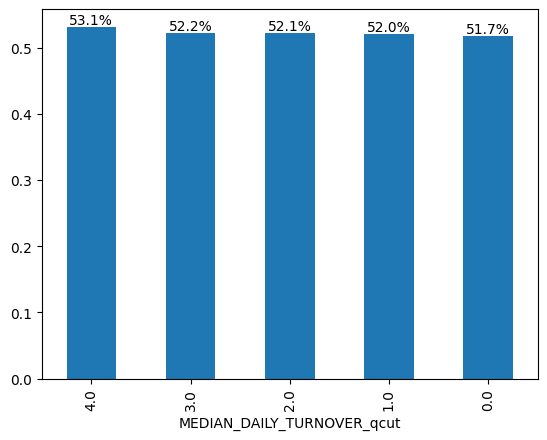

In [291]:
ax = (
    diagnostic_df.groupby('MEDIAN_DAILY_TURNOVER_qcut')["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar")
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

In [292]:
X_final_train = df_train_train.copy()
X_final_test = df_train_holdout.copy()

y_final_train = df_train_train[TARGET_BINARY].squeeze()
y_final_test = df_train_holdout[TARGET_BINARY].squeeze()

X_final_train = build_features(X_final_train)
X_final_test = build_features(X_final_test)

X_final_train = X_final_train[UTILS_COLS + features]
X_test_fold = X_final_test[UTILS_COLS + features]

X_final_train = preprocess(X_final_train).fillna(0)[features]
X_final_test = preprocess(X_final_test).fillna(0)[features]

#### Standardizing

scaler = StandardScaler()

X_final_train = scaler.fit_transform(X_final_train)
X_final_test = scaler.transform(X_final_test)

####

final_model = clone(model).fit(X_final_train, y_final_train)

y_train_proba = final_model.predict_proba(X_final_train)[:, 1]
y_test_proba = final_model.predict_proba(X_final_test)[:, 1]

thresh = 0.5
y_train_preds = (y_train_proba >= thresh).astype(int)
y_test_preds = (y_test_proba >= thresh).astype(int)


score_train = accuracy_score(df_train_train[TARGET_BINARY], y_train_preds)
score_test = accuracy_score(df_train_holdout[TARGET_BINARY], y_test_preds)

print(f"Accuracy train: {score_train:.6f} | Accuracy test: {score_test:.6f}")

Accuracy train: 0.524871 | Accuracy test: 0.513540


In [293]:
X_final_train = df_train.copy()
X_final_test = X_test.copy()

y_final_train = df_train[TARGET_BINARY].squeeze()

X_final_train = build_features(X_final_train)
X_final_test = build_features(X_final_test)

X_final_train = X_final_train[UTILS_COLS + features]
X_test_fold = X_final_test[UTILS_COLS + features]

X_final_train = preprocess(X_final_train).fillna(0)[features]
X_final_test = preprocess(X_final_test).fillna(0)[features]

#### Standardizing

scaler = StandardScaler()

X_final_train = scaler.fit_transform(X_final_train)
X_final_test = scaler.transform(X_final_test)

####

final_model = clone(model).fit(X_final_train, y_final_train)



preds_final = final_model.predict(X_final_test)
preds_final = pd.DataFrame(preds_final, index=sample_submission.index,columns=['target']) 

import datetime as dt 
now = dt.datetime.now()
preds_final.to_csv(f'preds_{now}.csv')